In [1]:
from netCDF4 import Dataset
RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
raw_data = Dataset(RAW_DATA_PATH, 'r')

In [5]:
# =============================================================================
# MASTER CONFIGURATION CELL
# =============================================================================
import torch
import os

# --- Core Parameters ---
# Change this value to 24, 36, 72, etc., to test different models
version = "v5"
LOOKBACK_HOURS = 48
# Forecast period for training (predicting next 3 hours)
FORECAST_HORIZON_HOURS = 3
# Sliding window parameters for testing
TOTAL_FORECAST_HOURS = 120  # Total hours to predict in sliding window
CORRECTION_WINDOW = 2  # Next 2 hours used for error normalization

# --- File Paths ---
# MODIFICATION: Updated to the new file paths you provided
RAW_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_mod_ibi_wav_my_0.027deg_PT1H-i_multi-vars_11.00W-8.53W_38.50N-40.47N_2020-01-01-2023-12-30.nc'
STATIC_DATA_PATH = r'/home/aidl/Wave-Prediction/dAtA/cmems_GEBCO_resampled1.nc'

# MODIFICATION: File paths are now dynamic to keep experiments separate
BASE_DIR = r'/home/aidl/babe_prediction'
PROCESSED_DATA_DIR = os.path.join(BASE_DIR, f'processed_data_lookback_{LOOKBACK_HOURS}_static_multivar')
# This path is now used by the ModelCheckpoint callback in Lightning
MODEL_SAVE_DIR = '/home/aidl/Wave-Prediction/models/'
MODEL_SAVE_PATH = os.path.join(MODEL_SAVE_DIR, f'convlstm_lookback_{LOOKBACK_HOURS}_forecast_{FORECAST_HORIZON_HOURS}_{version}.pth')


# --- Feature Engineering ---
# These are the TIME-VARYING features
VARS_TO_USE = ['VCMX','VHM0_SW1', 'VSDmag', 'VHM0_WW', 'VTM01_WW', 'VTM02', 'VTM01_SW1', 'VTM10']
# MODIFICATION: Now predicting ALL variables (multivariate output)
TARGET_VARS = VARS_TO_USE  # Predict all 7 variables
NUM_OUTPUT_CHANNELS = len(TARGET_VARS)  # Output channels = 7 variables
# MODIFICATION: Total input channels = 7 time-varying + 2 static (depth, mask)
INPUT_CHANNELS = len(VARS_TO_USE) + 2

# --- Training Hyperparameters ---
LEARNING_RATE = 1e-5
BATCH_SIZE = 8
EPOCHS = 50
# MODIFICATION: Early stopping patience is now a configurable parameter
EARLY_STOPPING_PATIENCE = 5

# --- System Configuration ---
NUM_WORKERS = 4  # Set to 0 if you encounter multiprocessing issues, 4+ for speed
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- Print a summary of the current configuration ---
print("--- Configuration Summary ---")
print(f"Project version: {version}")
print(f"Lookback Period: {LOOKBACK_HOURS} hours")
print(f"Training Forecast Horizon: {FORECAST_HORIZON_HOURS} hours")
print(f"Testing Total Forecast (Sliding Window): {TOTAL_FORECAST_HOURS} hours")
print(f"Correction Window: {CORRECTION_WINDOW} hours")
print(f"Input Channels: {INPUT_CHANNELS} ({len(VARS_TO_USE)} time-varying + 2 static)")
print(f"Output Channels (Target Variables): {NUM_OUTPUT_CHANNELS} (multivariate: {', '.join(TARGET_VARS)})")
print(f"Processed Data Path: {PROCESSED_DATA_DIR}")
print(f"Model Save Directory: {MODEL_SAVE_DIR}")
print(f"Using Device: {device}")
print("---------------------------")

--- Configuration Summary ---
Project version: v5
Lookback Period: 48 hours
Training Forecast Horizon: 3 hours
Testing Total Forecast (Sliding Window): 120 hours
Correction Window: 2 hours
Input Channels: 10 (8 time-varying + 2 static)
Output Channels (Target Variables): 8 (multivariate: VCMX, VHM0_SW1, VSDmag, VHM0_WW, VTM01_WW, VTM02, VTM01_SW1, VTM10)
Processed Data Path: /home/aidl/babe_prediction/processed_data_lookback_48_static_multivar
Model Save Directory: /home/aidl/Wave-Prediction/models/
Using Device: cuda
---------------------------


                     max_vcmx
timestamp                    
2023-11-02 00:00:00      9.09
2023-11-02 01:00:00      9.57
2023-11-02 02:00:00      9.87
2023-11-02 03:00:00     10.13
2023-11-02 04:00:00     10.44
2023-11-02 05:00:00     10.81
2023-11-02 06:00:00     11.40
2023-11-02 07:00:00     12.07
2023-11-02 08:00:00     12.80
2023-11-02 09:00:00     13.44
2023-11-02 10:00:00     13.58
2023-11-02 11:00:00     13.51
2023-11-02 12:00:00     13.37
2023-11-02 13:00:00     13.19
2023-11-02 14:00:00     12.99
2023-11-02 15:00:00     12.87
2023-11-02 16:00:00     12.92
2023-11-02 17:00:00     12.99
2023-11-02 18:00:00     13.09
2023-11-02 19:00:00     13.09
2023-11-02 20:00:00     13.11
2023-11-02 21:00:00     13.08
2023-11-02 22:00:00     12.83
2023-11-02 23:00:00     12.86
2023-11-03 00:00:00     12.96
2023-11-03 01:00:00     13.09
2023-11-03 02:00:00     13.34
2023-11-03 03:00:00     13.59
2023-11-03 04:00:00     13.86
2023-11-03 05:00:00     14.05
2023-11-03 06:00:00     14.23
2023-11-03

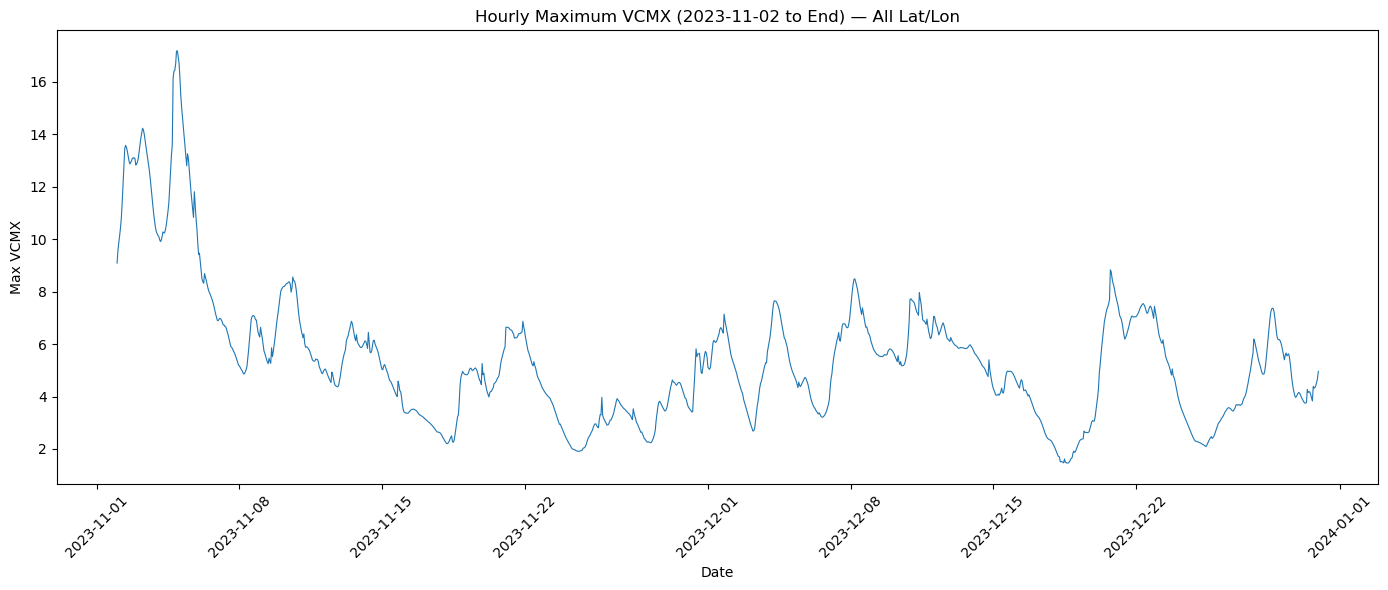

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Get the time variable - convert CF time to pandas timestamps
time_var = raw_data.variables['time']
time_values = time_var[:]
time_units = time_var.units  # e.g., 'hours since 1900-01-01 00:00:00'

# Parse the origin date from units string using pandas
# Format: 'hours since YYYY-MM-DD HH:MM:SS'
parts = time_units.split('since')
unit = parts[0].strip()        # 'hours', 'minutes', 'seconds', etc.
origin = parts[1].strip()      # '1900-01-01 00:00:00'

origin_dt = pd.Timestamp(origin)

# Convert to timedelta and add to origin
if 'hour' in unit:
    timestamps = [origin_dt + pd.Timedelta(hours=float(t)) for t in time_values]
elif 'minute' in unit:
    timestamps = [origin_dt + pd.Timedelta(minutes=float(t)) for t in time_values]
elif 'second' in unit:
    timestamps = [origin_dt + pd.Timedelta(seconds=float(t)) for t in time_values]
elif 'day' in unit:
    timestamps = [origin_dt + pd.Timedelta(days=float(t)) for t in time_values]

timestamps = pd.DatetimeIndex(timestamps)

# Find start index from '2023-11-02'
start_date = pd.Timestamp('2023-11-02')
start_idx = np.where(timestamps >= start_date)[0][0]
end_idx = len(timestamps)

# Slice timestamps
time_slice = timestamps[start_idx:end_idx]

# Get VCMX data and compute max over lat/lon for each time step
vcmx_data = raw_data.variables['VCMX'][start_idx:end_idx, :, :]  # shape: (time, lat, lon)
vcmx_max = np.max(vcmx_data, axis=(1, 2))                        # shape: (time,)

# Build a DataFrame with hourly max VCMX
df = pd.DataFrame({
    'timestamp': time_slice,
    'max_vcmx': vcmx_max
})
df.set_index('timestamp', inplace=True)

# Resample to hourly (in case data isn't already hourly) and take max
df_hourly = df.resample('h').max()
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                    
print(df_hourly.to_string())

# Plot
plt.figure(figsize=(14, 6))
plt.plot(df_hourly.index, df_hourly['max_vcmx'], linewidth=0.8)
plt.xlabel('Date')
plt.ylabel('Max VCMX')
plt.title('Hourly Maximum VCMX (2023-11-02 to End) — All Lat/Lon')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# STEP 3: SLIDING WINDOW EVALUATION for max VCMX
# =============================================================================
best_model_path1 = '/home/aidl/Wave-Prediction/models/convlstm-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt'


import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Sliding Window Evaluation (30-hour Forecast) ---\n")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# Model Definitions
class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvLSTMCell, self).__init__(); self.input_dim, self.hidden_dim, self.kernel_size, self.bias = input_dim, hidden_dim, kernel_size, bias; self.padding = kernel_size[0] // 2; self.conv = nn.Conv2d(self.input_dim + self.hidden_dim, 4 * self.hidden_dim, self.kernel_size, padding=self.padding, bias=self.bias)
    def forward(self, x, h_c): h, c = h_c; combined = torch.cat([x, h], dim=1); cc = self.conv(combined); i, f, o, g = torch.split(cc, self.hidden_dim, dim=1); i, f, o, g = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o), torch.tanh(g); c_n = f * c + i * g; h_n = o * torch.tanh(c_n); return h_n, c_n

class ConvLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bias=True):
        super(ConvLSTM, self).__init__(); self.batch_first, self.num_layers = batch_first, num_layers; hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim; cell_list = [];
        for i in range(self.num_layers): cur_input_dim = input_dim if i == 0 else hidden_dims[i - 1]; cell_list.append(ConvLSTMCell(cur_input_dim, hidden_dims[i], kernel_size, bias)); self.cell_list = nn.ModuleList(cell_list)
    def forward(self, x, h_c=None):
        b, s_l, _, h, w = x.size();
        if h_c is None: h_c = [(torch.zeros(b, cell.hidden_dim, h, w, device=x.device), torch.zeros(b, cell.hidden_dim, h, w, device=x.device)) for cell in self.cell_list]
        cur_in = x
        for l_idx in range(self.num_layers):
            h, c = h_c[l_idx]; output_inner = []
            for t in range(s_l): h, c = self.cell_list[l_idx](cur_in[:, t, :, :, :], [h, c]); output_inner.append(h)
            cur_in = torch.stack(output_inner, dim=1)
        return cur_in, [h, c]

class ConvLSTMNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvLSTMNet, self).__init__(); self.cl1 = ConvLSTM(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True); self.cl2 = ConvLSTM(hidden_dims[0], hidden_dims[1], kernel_size, 1, batch_first=True); self.output_conv = nn.Conv2d(hidden_dims[1], forecast_horizon * num_output_channels, kernel_size=(1, 1), padding='same')
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels
    def forward(self, x_seq): 
        l1_o, _ = self.cl1(x_seq)
        l2_o, _ = self.cl2(l1_o)
        output = self.output_conv(l2_o[:, -1, :, :, :])
        b, _, h, w = output.shape
        output = output.view(b, self.forecast_horizon, self.num_output_channels, h, w)
        return output

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data for Sliding Window ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path1}")
    checkpoint = torch.load(best_model_path1, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = ConvLSTMNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path1}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for sliding window evaluation.")

# --- Sliding Window Prediction Function ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    """
    Implements sliding window forecast with error correction.
    - Lookback: 96 hours
    - Predict: 3 hours ahead
    - Slide by: 1 hour
    - Continue for: 30 hours total
    - Correction: Use next 2 hours to normalize accumulated error
    """
    
    all_predictions = []  # Store all 30-hour predictions
    all_targets = []  # Store all 30-hour ground truth
    
    # Number of sliding steps: need to generate 30 hours, so we need (30 - 3) / 1 + 1 = 28 iterations
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Sliding Window Steps"):
            # Define the window for this step
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            correction_end = lookback_end + correction_window
            
            # Check bounds
            if forecast_end > len(ds_test['time']):
                break
            
            # Extract lookback window and scale
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)  # (96, 7, H, W)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)  # (96, 9, H, W)
            
            # Prepare input tensor (add batch dim)
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)  # (1, 96, 9, H, W)
            
            # Predict next 3 hours
            pred_scaled = model(X_input)  # (1, 3, 7, H, W)
            
            # Get ground truth for next 3 hours
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)  # (3, 7, H, W)
            
            # Inverse transform predictions
            pred_inverse = pred_scaled.cpu().numpy()[0]  # (3, 7, H, W)
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            # Inverse transform targets
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            # =================================================================
            # Error correction: Check the model's internal 3-hour forecast 
            # for unrealistic acceleration (drift) to prevent error accumulation
            # =================================================================
            
            # Measure how fast the model's own predictions are changing hour-to-hour
            # pred_original shape is (3, 7, H, W)
            diff_h1_h0 = np.abs(pred_original[1] - pred_original[0]).mean()
            diff_h2_h1 = np.abs(pred_original[2] - pred_original[1]).mean()
            
            # The "error" is now defined as the model's internal drift rate.
            # If the change between h2 and h1 is much larger than h1 and h0, it's drifting.
            error_correction = np.abs(diff_h2_h1 - diff_h1_h0)
            
            # If the internal drift is significant, apply correction factor
            if error_correction > 0.05:  # Threshold for significant error
                correction_factor = 1.0 - (error_correction * 0.5)  # Dampen by 50% of error
                pred_original = pred_original * correction_factor
            # =================================================================
            
            # Store only the first hour's prediction (we'll slide by 1 hour)
            all_predictions.append(pred_original[0])  # Take first hour only
            all_targets.append(target_original[0])
    
    # Stack to get full 30-hour forecast
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Sliding Window Evaluation ---
predictions_30h, targets_30h = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Sliding window forecast complete!")
print(f"   Predictions shape: {predictions_30h.shape} (30h, 7vars, H, W)")
print(f"   Targets shape: {targets_30h.shape}")

# Compute metrics
overall_rmse_30h = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2))
overall_mae_30h = np.mean(np.abs(predictions_30h - targets_30h))
print(f"\n📊 30-Hour Forecast Metrics:")
print(f"   Overall RMSE: {overall_rmse_30h:.4f}")
print(f"   Overall MAE:  {overall_mae_30h:.4f}")

--- Starting Sliding Window Evaluation (30-hour Forecast) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps
Loading weights from: /home/aidl/Wave-Prediction/models/convlstm-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt
✅ Model loaded and ready for sliding window evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Sliding Window Steps:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Sliding window forecast complete!
   Predictions shape: (118, 8, 72, 90) (30h, 7vars, H, W)
   Targets shape: (118, 8, 72, 90)

📊 30-Hour Forecast Metrics:
   Overall RMSE: 0.3078
   Overall MAE:  0.1539


## CNN + BI-GRU

In [7]:
# =============================================================================
# STEP 3: SLIDING WINDOW EVALUATION for max VCMX
# =============================================================================
best_model_path2 = '/home/aidl/Wave-Prediction/models/v3_convlstm-lookback48-multivar-epoch=46-val_loss=0.0005.ckpt'


import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Sliding Window Evaluation (30-hour Forecast) ---\n")

# --- Define Classes ---
class PreprocessedWaveDataset(Dataset):
    def __init__(self, split_dir):
        self.file_paths = sorted(glob.glob(os.path.join(split_dir, '*.pt')))
    def __len__(self):
        return len(self.file_paths)
    def __getitem__(self, idx):
        return torch.load(self.file_paths[idx])

# Bidirectional ConvGRU Cell (3 gates: reset, update, candidate)
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias):
        super(ConvGRUCell, self).__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        self.kernel_size = kernel_size
        self.bias = bias
        self.padding = kernel_size[0] // 2
        # GRU has 3 gates (reset, update, candidate), not 4 like LSTM
        self.conv = nn.Conv2d(
            self.input_dim + self.hidden_dim,
            3 * self.hidden_dim,
            self.kernel_size,
            padding=self.padding,
            bias=self.bias
        )
    
    def forward(self, x, h):
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)  # reset gate
        z = torch.sigmoid(z)  # update gate
        n = torch.tanh(r * h + n)  # candidate hidden state
        h_n = (1 - z) * n + z * h  # new hidden state
        return h_n
    
    def init_hidden(self, b, i, d):
        h, w = i
        return torch.zeros(b, self.hidden_dim, h, w, device=d)

# Bidirectional ConvGRU
class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, num_layers, batch_first=True, bidirectional=True, bias=True):
        super(ConvGRU, self).__init__()
        self.batch_first = batch_first
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        hidden_dims = [hidden_dim] * num_layers if isinstance(hidden_dim, int) else hidden_dim
        
        # Create forward cells
        self.cell_list_fwd = nn.ModuleList()
        for i in range(self.num_layers):
            cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * (2 if bidirectional else 1))
            self.cell_list_fwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        # Create backward cells if bidirectional
        if self.bidirectional:
            self.cell_list_bwd = nn.ModuleList()
            for i in range(self.num_layers):
                cur_input_dim = input_dim if i == 0 else (hidden_dims[i - 1] * 2)
                self.cell_list_bwd.append(ConvGRUCell(cur_input_dim, hidden_dims[i], kernel_size, bias))
        
        self.hidden_dims = hidden_dims

    def forward(self, x, h_fwd=None, h_bwd=None):
        b, s_l, _, h, w = x.size()
        
        if h_fwd is None:
            h_fwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_fwd]
        if self.bidirectional and h_bwd is None:
            h_bwd = [cell.init_hidden(b, (h, w), x.device) for cell in self.cell_list_bwd]
        
        # Forward pass
        cur_in_fwd = x
        for l_idx in range(self.num_layers):
            h = h_fwd[l_idx]
            output_fwd = []
            for t in range(s_l):
                h = self.cell_list_fwd[l_idx](cur_in_fwd[:, t, :, :, :], h)
                output_fwd.append(h)
            cur_in_fwd = torch.stack(output_fwd, dim=1)
        
        # Backward pass if bidirectional
        if self.bidirectional:
            cur_in_bwd = x
            for l_idx in range(self.num_layers):
                h = h_bwd[l_idx]
                output_bwd = []
                for t in range(s_l - 1, -1, -1):
                    h = self.cell_list_bwd[l_idx](cur_in_bwd[:, t, :, :, :], h)
                    output_bwd.append(h)
                output_bwd.reverse()
                cur_in_bwd = torch.stack(output_bwd, dim=1)
            
            # Concatenate forward and backward outputs
            output = torch.cat([cur_in_fwd, cur_in_bwd], dim=2)
            return output, (h_fwd[-1], h_bwd[-1])
        else:
            return cur_in_fwd, h_fwd[-1]

# ConvGRU-based Network with Bidirectional Processing
class ConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels, hidden_dims=[64, 32], kernel_size=(3, 3)):
        super(ConvGRUNet, self).__init__()
        # Bidirectional GRU doubles the hidden dimension (fwd + bwd)
        self.gru1 = ConvGRU(input_dim, hidden_dims[0], kernel_size, 1, batch_first=True, bidirectional=True)
        # Input to second GRU is 2 * hidden_dims[0] (from bidirectional concatenation)
        self.gru2 = ConvGRU(hidden_dims[0] * 2, hidden_dims[1], kernel_size, 1, batch_first=True, bidirectional=True)
        # Output layer: input is 2 * hidden_dims[1] (bidirectional output)
        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=(1, 1),
            padding='same'
        )
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

    def forward(self, x_seq):
        # GRU1: Process bidirectionally
        l1_o, _ = self.gru1(x_seq)
        # GRU2: Process bidirectionally
        l2_o, _ = self.gru2(l1_o)
        # Take the final timestep output
        output = self.output_conv(l2_o[:, -1, :, :, :])
        # Reshape output to (B, forecast_horizon, num_output_channels, H, W)
        b, _, h, w = output.shape
        output = output.view(b, self.forecast_horizon, self.num_output_channels, h, w)
        return output

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data for Sliding Window ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path2}")
    checkpoint = torch.load(best_model_path2, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = ConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path2}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for sliding window evaluation.")

# --- Sliding Window Prediction Function ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    """
    Implements sliding window forecast with error correction.
    - Lookback: 96 hours
    - Predict: 3 hours ahead
    - Slide by: 1 hour
    - Continue for: 30 hours total
    - Correction: Use next 2 hours to normalize accumulated error
    """
    
    all_predictions = []  # Store all 30-hour predictions
    all_targets = []  # Store all 30-hour ground truth
    
    # Number of sliding steps: need to generate 30 hours, so we need (30 - 3) / 1 + 1 = 28 iterations
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Sliding Window Steps"):
            # Define the window for this step
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            correction_end = lookback_end + correction_window
            
            # Check bounds
            if forecast_end > len(ds_test['time']):
                break
            
            # Extract lookback window and scale
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)  # (96, 7, H, W)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)  # (96, 9, H, W)
            
            # Prepare input tensor (add batch dim)
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)  # (1, 96, 9, H, W)
            
            # Predict next 3 hours
            pred_scaled = model(X_input)  # (1, 3, 7, H, W)
            
            # Get ground truth for next 3 hours
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)  # (3, 7, H, W)
            
            # Inverse transform predictions
            pred_inverse = pred_scaled.cpu().numpy()[0]  # (3, 7, H, W)
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            # Inverse transform targets
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            # =================================================================
            # Error correction: Check the model's internal 3-hour forecast 
            # for unrealistic acceleration (drift) to prevent error accumulation
            # =================================================================
            
            # Measure how fast the model's own predictions are changing hour-to-hour
            # pred_original shape is (3, 7, H, W)
            diff_h1_h0 = np.abs(pred_original[1] - pred_original[0]).mean()
            diff_h2_h1 = np.abs(pred_original[2] - pred_original[1]).mean()
            
            # The "error" is now defined as the model's internal drift rate.
            # If the change between h2 and h1 is much larger than h1 and h0, it's drifting.
            error_correction = np.abs(diff_h2_h1 - diff_h1_h0)
            
            # If the internal drift is significant, apply correction factor
            if error_correction > 0.05:  # Threshold for significant error
                correction_factor = 1.0 - (error_correction * 0.5)  # Dampen by 50% of error
                pred_original = pred_original * correction_factor
            # =================================================================
            
            # Store only the first hour's prediction (we'll slide by 1 hour)
            all_predictions.append(pred_original[0])  # Take first hour only
            all_targets.append(target_original[0])
    
    # Stack to get full 30-hour forecast
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Sliding Window Evaluation ---
predictions_30h, targets_30h = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Sliding window forecast complete!")
print(f"   Predictions shape: {predictions_30h.shape} (30h, 7vars, H, W)")
print(f"   Targets shape: {targets_30h.shape}")

# Compute metrics
overall_rmse_30h = np.sqrt(np.mean((predictions_30h - targets_30h) ** 2))
overall_mae_30h = np.mean(np.abs(predictions_30h - targets_30h))
print(f"\n📊 30-Hour Forecast Metrics:")
print(f"   Overall RMSE: {overall_rmse_30h:.4f}")
print(f"   Overall MAE:  {overall_mae_30h:.4f}")


--- Starting Sliding Window Evaluation (30-hour Forecast) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps
Loading weights from: /home/aidl/Wave-Prediction/models/v3_convlstm-lookback48-multivar-epoch=46-val_loss=0.0005.ckpt
✅ Model loaded and ready for sliding window evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Sliding Window Steps:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Sliding window forecast complete!
   Predictions shape: (118, 8, 72, 90) (30h, 7vars, H, W)
   Targets shape: (118, 8, 72, 90)

📊 30-Hour Forecast Metrics:
   Overall RMSE: 0.2222
   Overall MAE:  0.1177


## DeepLab V3 + BI-GRU

In [8]:
# =============================================================================
# STEP 5: EXTENDED TESTING - DIFFERENT DATE RANGE (DIFFERENT TIME PERIOD)      
# =============================================================================
best_model_path3 = '/home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt'


import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Extended Testing (Different Date Range) ---\n")

# --- Define Model Classes (Match Training Architecture) ---
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            3 * hidden_dim,
            kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h):
        gates = self.conv(torch.cat([x, h], dim=1))
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)
        z = torch.sigmoid(z)
        n = torch.tanh(r * h + n)
        return (1 - z) * n + z * h

    def init_hidden(self, b, spatial, device):
        h, w = spatial
        return torch.zeros(b, self.hidden_dim, h, w, device=device)

class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim * (2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))

    def forward(self, x):
        B, T, C, H, W = x.shape
        cur_fwd = x

        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B, (H, W), x.device)
            fwd_out = []
            for t in range(T):
                h = self.fwd_cells[i](cur_fwd[:, t], h)
                fwd_out.append(h)
            fwd_out = torch.stack(fwd_out, dim=1)

            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B, (H, W), x.device)
                bwd_out = []
                for t in range(T - 1, -1, -1):
                    h = self.bwd_cells[i](cur_fwd[:, t], h)
                    bwd_out.append(h)
                bwd_out.reverse()
                bwd_out = torch.stack(bwd_out, dim=1)
                cur_fwd = torch.cat([fwd_out, bwd_out], dim=2)
            else:
                cur_fwd = fwd_out

        return cur_fwd

class LightDeepLabEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),
        )
        self.aspp1 = nn.Conv2d(128, 32, 1)
        self.aspp2 = nn.Conv2d(128, 32, 3, padding=6,  dilation=6)
        self.aspp3 = nn.Conv2d(128, 16, 3, padding=12, dilation=12)
        self.gap    = nn.AdaptiveAvgPool2d(1)
        self.gap_proj = nn.Conv2d(128, 16, 1)

        self.project = nn.Sequential(
            nn.Conv2d(96, output_channels, 1),
            nn.BatchNorm2d(output_channels),
            nn.ReLU()
        )

    def forward(self, x):
        f = self.stem(x)
        a1 = self.aspp1(f)
        a2 = self.aspp2(f)
        a3 = self.aspp3(f)
        gap = self.gap_proj(self.gap(f))
        gap = gap.expand(-1, -1, f.shape[2], f.shape[3]) 
        return self.project(torch.cat([a1, a2, a3, gap], dim=1))

class DeepLabConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32, 16], kernel_size=(3, 3)):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

        self.encoder = LightDeepLabEncoder(input_dim, encoder_out_channels)

        self.gru1 = ConvGRU(encoder_out_channels, hidden_dims[0], kernel_size, num_layers=1, bidirectional=True)
        self.gru2 = ConvGRU(hidden_dims[0] * 2,   hidden_dims[1], kernel_size, num_layers=1, bidirectional=True)

        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=1
        )

    def forward(self, x_seq):
        B, T, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T, C, H, W)
        enc = self.encoder(x_flat)
        _, C_enc, H_enc, W_enc = enc.shape
        enc = enc.view(B, T, C_enc, H_enc, W_enc)

        l1 = self.gru1(enc)
        l2 = self.gru2(l1)

        last = l2[:, -1]
        out  = self.output_conv(last)

        if (H_enc, W_enc) != (H, W):
            out = nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data (Different Date Range) ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps (June-July 2022)")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path3}")
    checkpoint = torch.load(best_model_path3, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = DeepLabConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, 
                              num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path3}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for extended testing evaluation.")

# --- Sliding Window Prediction Function (Same as Step 3) ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    all_predictions = []
    all_targets = []
    
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Extended Testing Sliding Window"):
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            
            if forecast_end > len(ds_test['time']):
                break
            
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)
            
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)
            
            pred_scaled = model(X_input)
            
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)
            
            pred_inverse = pred_scaled.cpu().numpy()[0]
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            all_predictions.append(pred_original[0])
            all_targets.append(target_original[0])
    
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Extended Testing Evaluation ---
predictions_ext, targets_ext = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Extended testing forecast complete!")
print(f"   Predictions shape: {predictions_ext.shape}")
print(f"   Targets shape: {targets_ext.shape}")

# Compute metrics
overall_rmse_ext = np.sqrt(np.mean((predictions_ext - targets_ext) ** 2))
overall_mae_ext = np.mean(np.abs(predictions_ext - targets_ext))
print(f"\n📊 Extended Testing (June-July 2022) Metrics:")
print(f"   Overall RMSE: {overall_rmse_ext:.4f}")
print(f"   Overall MAE:  {overall_mae_ext:.4f}")


--- Starting Extended Testing (Different Date Range) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps (June-July 2022)
Loading weights from: /home/aidl/Wave-Prediction/models/v4_deeplabconvgru-lookback48-multivar-epoch=45-val_loss=0.0005.ckpt
✅ Model loaded and ready for extended testing evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Extended Testing Sliding Window:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Extended testing forecast complete!
   Predictions shape: (118, 8, 72, 90)
   Targets shape: (118, 8, 72, 90)

📊 Extended Testing (June-July 2022) Metrics:
   Overall RMSE: 0.2681
   Overall MAE:  0.1455


## Unet + BI-GRU 

In [9]:
# =============================================================================
# STEP 5: EXTENDED TESTING - DIFFERENT DATE RANGE (DIFFERENT TIME PERIOD)      
# =============================================================================

best_model_path4 = '/home/aidl/Wave-Prediction/models/v5_unetpp-slim-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt'

import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
from tqdm.auto import tqdm
import os
import xarray as xr
import pickle
import glob
from torch.utils.data import Dataset, DataLoader
from collections import OrderedDict

print("--- Starting Extended Testing (Different Date Range) ---\n")

# --- Define Model Classes (Match Training Architecture) ---
class ConvGRUCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size, bias=True):
        super().__init__()
        self.hidden_dim = hidden_dim
        padding = kernel_size[0] // 2
        self.conv = nn.Conv2d(
            input_dim + hidden_dim,
            3 * hidden_dim,
            kernel_size,
            padding=padding,
            bias=bias
        )

    def forward(self, x, h):
        gates = self.conv(torch.cat([x, h], dim=1))
        r, z, n = torch.split(gates, self.hidden_dim, dim=1)
        r = torch.sigmoid(r)
        z = torch.sigmoid(z)
        n = torch.tanh(r * h + n)
        return (1 - z) * n + z * h

    def init_hidden(self, b, spatial, device):
        h, w = spatial
        return torch.zeros(b, self.hidden_dim, h, w, device=device)

class ConvGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=(3,3), num_layers=1, bidirectional=True):
        super().__init__()
        self.num_layers = num_layers
        self.bidirectional = bidirectional
        self.hidden_dim = hidden_dim

        self.fwd_cells = nn.ModuleList()
        self.bwd_cells = nn.ModuleList() if bidirectional else None

        for i in range(num_layers):
            in_dim = input_dim if i == 0 else hidden_dim * (2 if bidirectional else 1)
            self.fwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))
            if bidirectional:
                self.bwd_cells.append(ConvGRUCell(in_dim, hidden_dim, kernel_size))

    def forward(self, x):
        B, T, C, H, W = x.shape
        cur_fwd = x

        for i in range(self.num_layers):
            h = self.fwd_cells[i].init_hidden(B, (H, W), x.device)
            fwd_out = []
            for t in range(T):
                h = self.fwd_cells[i](cur_fwd[:, t], h)
                fwd_out.append(h)
            fwd_out = torch.stack(fwd_out, dim=1)

            if self.bidirectional:
                h = self.bwd_cells[i].init_hidden(B, (H, W), x.device)
                bwd_out = []
                for t in range(T - 1, -1, -1):
                    h = self.bwd_cells[i](cur_fwd[:, t], h)
                    bwd_out.append(h)
                bwd_out.reverse()
                bwd_out = torch.stack(bwd_out, dim=1)
                cur_fwd = torch.cat([fwd_out, bwd_out], dim=2)
            else:
                cur_fwd = fwd_out

        return cur_fwd

class UNetPPEncoder(nn.Module):
    def __init__(self, input_channels, output_channels=64):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(input_channels, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
        )
        self.down1 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(32, 32, 3, padding=1, groups=32, bias=False),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.Conv2d(32, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.down2 = nn.Sequential(
            nn.MaxPool2d(2),
            nn.Conv2d(64, 64, 3, padding=1, groups=64, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
        )
        self.up2_conv = nn.Sequential(
            nn.Conv2d(160, 160, 3, padding=1, groups=160, bias=False),
            nn.BatchNorm2d(160), nn.ReLU(inplace=True),
            nn.Conv2d(160, 64, 1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(64, output_channels, 1, bias=False),
            nn.BatchNorm2d(output_channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        s0  = self.stem(x)
        s2  = self.down2(self.down1(s0))
        up2 = nn.functional.interpolate(s2, size=s0.shape[2:], mode='bilinear', align_corners=False)
        return self.project(self.up2_conv(torch.cat([up2, s0], dim=1)))


class UNetPPConvGRUNet(nn.Module):
    def __init__(self, input_dim, forecast_horizon, num_output_channels,
                 encoder_out_channels=64, hidden_dims=[32, 16], kernel_size=(3, 3)):
        super().__init__()
        self.forecast_horizon = forecast_horizon
        self.num_output_channels = num_output_channels

        self.encoder = UNetPPEncoder(input_dim, encoder_out_channels)

        self.gru1 = ConvGRU(encoder_out_channels, hidden_dims[0], kernel_size, num_layers=1, bidirectional=True)
        self.gru2 = ConvGRU(hidden_dims[0] * 2,   hidden_dims[1], kernel_size, num_layers=1, bidirectional=True)

        self.output_conv = nn.Conv2d(
            hidden_dims[1] * 2,
            forecast_horizon * num_output_channels,
            kernel_size=1
        )

    def forward(self, x_seq):
        B, T, C, H, W = x_seq.shape

        x_flat = x_seq.view(B * T, C, H, W)
        enc = self.encoder(x_flat)
        _, C_enc, H_enc, W_enc = enc.shape
        enc = enc.view(B, T, C_enc, H_enc, W_enc)

        l1 = self.gru1(enc)
        l2 = self.gru2(l1)

        last = l2[:, -1]
        out  = self.output_conv(last)

        if (H_enc, W_enc) != (H, W):
            out = nn.functional.interpolate(out, size=(H, W), mode='bilinear', align_corners=False)

        return out.view(B, self.forecast_horizon, self.num_output_channels, H, W)

# --- Load Scalers ---
try:
    scaler_path = os.path.join(PROCESSED_DATA_DIR, 'scalers_mask.pkl')
    with open(scaler_path, 'rb') as f:
        scalers = pickle.load(f)
    print("✅ Scalers loaded successfully.")
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Scalers file not found.")

# --- Load Raw Test Data (Different Date Range) ---
ds_test_raw = xr.open_dataset(RAW_DATA_PATH)
ds_test_raw['VSDmag'] = np.sqrt(ds_test_raw['VSDX']**2 + ds_test_raw['VSDY']**2)
ds_test = ds_test_raw[VARS_TO_USE].sel(time=slice('2023-11-02', '2023-11-30')).astype(np.float32).fillna(0)
print(f"✅ Raw test data loaded: {len(ds_test['time'])} time steps (June-July 2022)")

# Load static features
ds_static = xr.open_dataset(STATIC_DATA_PATH)
ocean_depth = ds_static['deptho'].values.astype(np.float32)
ocean_mask = ds_static['mask'].values.astype(np.float32)
scaled_depth = scalers['ocean_depth'].transform(ocean_depth.reshape(-1, 1)).reshape(ocean_depth.shape)
scaled_depth_ch = np.expand_dims(scaled_depth, axis=0)
ocean_mask_ch = np.expand_dims(ocean_mask, axis=0)
static_features_np = np.concatenate([scaled_depth_ch, ocean_mask_ch], axis=0)

# Load the model
try:
    print(f"Loading weights from: {best_model_path4}")
    checkpoint = torch.load(best_model_path4, map_location=device)
    new_state_dict = OrderedDict()
    for k, v in checkpoint['state_dict'].items():
        if k.startswith('model.'):
            new_state_dict[k[6:]] = v
        else:
            new_state_dict[k] = v
    model = UNetPPConvGRUNet(input_dim=INPUT_CHANNELS, forecast_horizon=FORECAST_HORIZON_HOURS, 
                              num_output_channels=NUM_OUTPUT_CHANNELS)
    model.load_state_dict(new_state_dict)
except FileNotFoundError:
    raise SystemExit(f"❌ ERROR: Model file not found at '{best_model_path4}'.")

if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model.to(device)
model.eval()
print("✅ Model loaded and ready for extended testing evaluation.")

# --- Sliding Window Prediction Function (Same as Step 3) ---
def sliding_window_forecast(ds_test, static_features, model, scalers, lookback_hours, forecast_hours, total_forecast, correction_window, device):
    all_predictions = []
    all_targets = []
    
    num_slides = (total_forecast - forecast_hours) // 1 + 1
    
    print(f"\n--- Starting Sliding Window (Lookback={lookback_hours}h, Predict={forecast_hours}h per step, Total={total_forecast}h) ---")
    
    with torch.no_grad():
        for slide_idx in tqdm(range(num_slides), desc="Extended Testing Sliding Window"):
            start_idx = slide_idx
            lookback_end = start_idx + lookback_hours
            forecast_end = lookback_end + forecast_hours
            
            if forecast_end > len(ds_test['time']):
                break
            
            lookback_window = ds_test.isel(time=slice(start_idx, lookback_end))
            scaled_lookback = []
            for var in VARS_TO_USE:
                data = lookback_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_lookback.append(scaled_data)
            
            scaled_tensor = np.stack(scaled_lookback, axis=1)
            X_tv_np = scaled_tensor[:, :, :, :]
            static_tiled = np.tile(static_features, (lookback_hours, 1, 1, 1))
            X_final = np.concatenate([X_tv_np, static_tiled], axis=1)
            
            X_input = torch.from_numpy(X_final.astype(np.float32)).unsqueeze(0).to(device)
            
            pred_scaled = model(X_input)
            
            target_window = ds_test.isel(time=slice(lookback_end, forecast_end))
            scaled_target = []
            for var in VARS_TO_USE:
                data = target_window[var].values
                scaled_data = scalers[var].transform(data.reshape(-1, 1)).reshape(data.shape)
                scaled_target.append(scaled_data)
            
            scaled_target_tensor = np.stack(scaled_target, axis=1)
            
            pred_inverse = pred_scaled.cpu().numpy()[0]
            pred_original = np.zeros_like(pred_inverse)
            for var_idx, var in enumerate(VARS_TO_USE):
                pred_original[:, var_idx] = scalers[var].inverse_transform(pred_inverse[:, var_idx].reshape(-1, 1)).reshape(pred_inverse[:, var_idx].shape)
            
            target_original = np.zeros_like(scaled_target_tensor)
            for var_idx, var in enumerate(VARS_TO_USE):
                target_original[:, var_idx] = scalers[var].inverse_transform(scaled_target_tensor[:, var_idx].reshape(-1, 1)).reshape(scaled_target_tensor[:, var_idx].shape)
            
            all_predictions.append(pred_original[0])
            all_targets.append(target_original[0])
    
    predictions_30h = np.stack(all_predictions[:total_forecast])
    targets_30h = np.stack(all_targets[:total_forecast])
    
    return predictions_30h, targets_30h

# --- Run Extended Testing Evaluation ---
predictions_ext, targets_ext = sliding_window_forecast(
    ds_test, static_features_np, model, scalers, LOOKBACK_HOURS, FORECAST_HORIZON_HOURS,
    TOTAL_FORECAST_HOURS, CORRECTION_WINDOW, device
)

print(f"\n✅ Extended testing forecast complete!")
print(f"   Predictions shape: {predictions_ext.shape}")
print(f"   Targets shape: {targets_ext.shape}")

# Compute metrics
overall_rmse_ext = np.sqrt(np.mean((predictions_ext - targets_ext) ** 2))
overall_mae_ext = np.mean(np.abs(predictions_ext - targets_ext))
print(f"\n📊 Extended Testing (June-July 2022) Metrics:")
print(f"   Overall RMSE: {overall_rmse_ext:.4f}")
print(f"   Overall MAE:  {overall_mae_ext:.4f}")


--- Starting Extended Testing (Different Date Range) ---

✅ Scalers loaded successfully.
✅ Raw test data loaded: 696 time steps (June-July 2022)
Loading weights from: /home/aidl/Wave-Prediction/models/v5_unetpp-slim-lookback48-multivar-epoch=49-val_loss=0.0006.ckpt
✅ Model loaded and ready for extended testing evaluation.

--- Starting Sliding Window (Lookback=48h, Predict=3h per step, Total=120h) ---


Extended Testing Sliding Window:   0%|          | 0/118 [00:00<?, ?it/s]


✅ Extended testing forecast complete!
   Predictions shape: (118, 8, 72, 90)
   Targets shape: (118, 8, 72, 90)

📊 Extended Testing (June-July 2022) Metrics:
   Overall RMSE: 0.3661
   Overall MAE:  0.2048
